### Explainability Summary

- Loads the trained **LightGBM** model and preprocessed test data from `model_comparison_v2`
- Computes SHAP values using TreeExplainer on a 500-sample subset
- Plots: global feature importance (bar), beeswarm summary, single prediction force plot, dependence plot
- Top 20 features by mean |SHAP| value

### Imports

In [8]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "numpy", "pandas", "joblib", "matplotlib", "scikit-learn", "shap", "lightgbm"])

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap

print(f"shap {shap.__version__}")
print("All imports OK.")

shap 0.51.0
All imports OK.


### Load LightGBM Model & Preprocessed Data

In [9]:
# Load LightGBM model, feature names, and preprocessed test array saved by model_comparison_v2
model         = joblib.load("models/airline_delay_lgbm.pkl")
feature_names = joblib.load("models/feature_names.pkl")
X_test_boost  = np.load("models/X_test_boost.npy")
y_test        = pd.read_csv("data/processed/y_test.csv").values.ravel()

print(f"Model type     : {type(model).__name__}")
print(f"Features       : {len(feature_names)}")
print(f"X_test shape   : {X_test_boost.shape}")
print(f"Feature names  : {feature_names[:5]} ...")

Model type     : LGBMClassifier
Features       : 35
X_test shape   : (98552, 35)
Feature names  : ['YEAR', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'DISTANCE'] ...


### Sample 500 Rows for SHAP (for speed)

In [10]:
SHAP_SAMPLE = 500
np.random.seed(42)
sample_idx = np.random.choice(X_test_boost.shape[0], SHAP_SAMPLE, replace=False)

# DataFrame with correct feature names for SHAP plots
X_shap = pd.DataFrame(X_test_boost[sample_idx], columns=feature_names)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (500, 35)


### Create SHAP TreeExplainer & Compute SHAP Values

In [11]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# For LightGBM binary classifier, shap_values is a list [class-0, class-1]
if isinstance(shap_values, list):
    sv = shap_values[1]  # class-1 (Delayed)
    base_val = explainer.expected_value[1]
else:
    sv = shap_values
    base_val = explainer.expected_value

print("SHAP values shape:", sv.shape)

SHAP values shape: (500, 35)


/Users/jiveshkarthik/Documents/Visual Studio Code/Sem 8/mini-project/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### Global Feature Importance – Bar Plot

/var/folders/0k/lbvs8t7s1rx9_rsngx67x2z00000gn/T/ipykernel_75928/3823195188.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


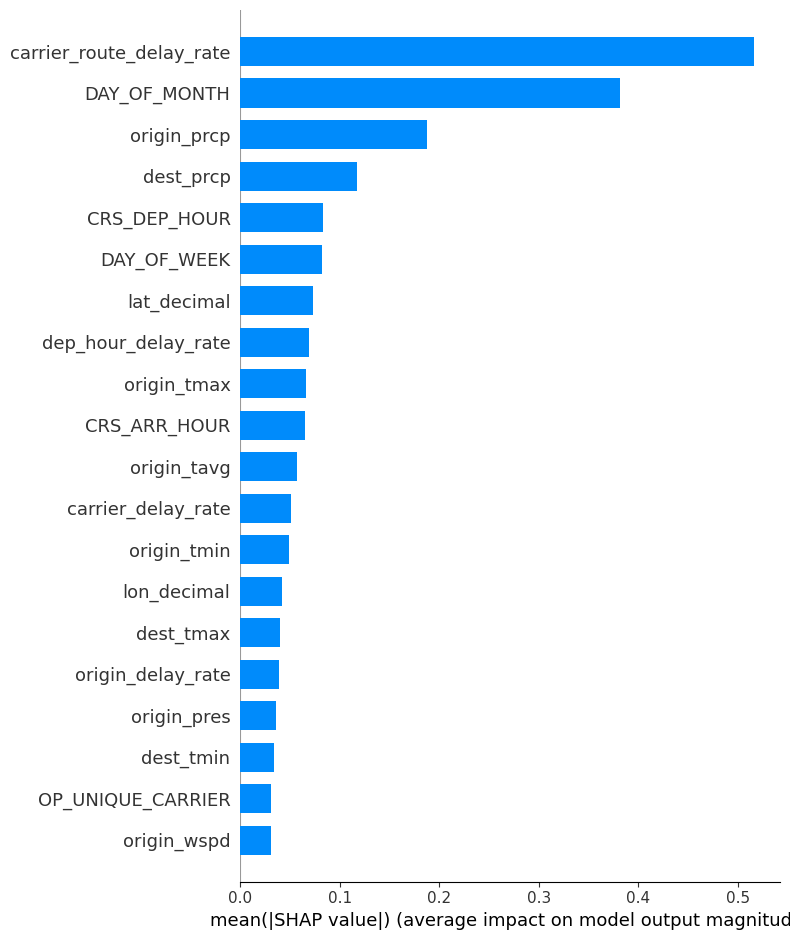

In [12]:
shap.summary_plot(
    sv,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=True
)

### Beeswarm Summary Plot

/var/folders/0k/lbvs8t7s1rx9_rsngx67x2z00000gn/T/ipykernel_75928/1595127612.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


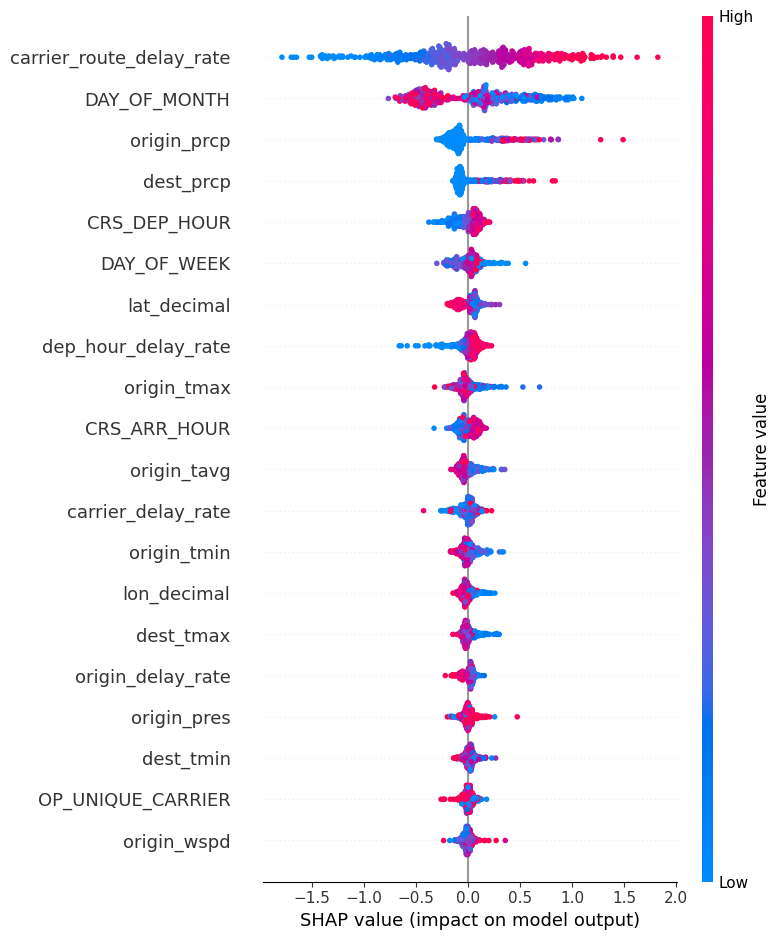

In [13]:
shap.summary_plot(
    sv,
    X_shap,
    feature_names=feature_names,
    max_display=20,
    show=True
)

### Single Prediction – Force Plot

Explains why the model made a specific prediction for one flight.

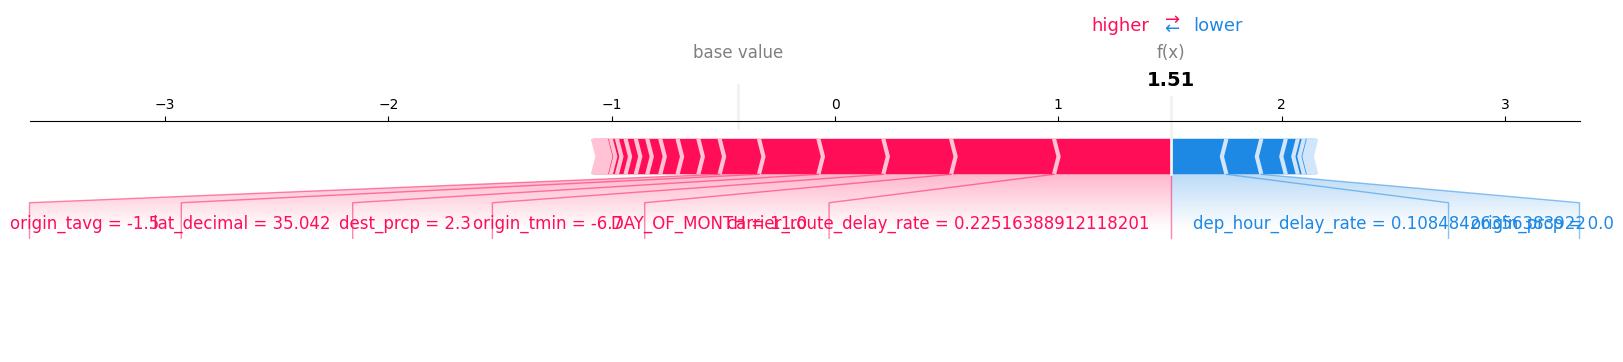

In [14]:
idx = 0  # change to inspect a different sample

shap.force_plot(
    base_val,
    sv[idx],
    X_shap.iloc[idx],
    matplotlib=True
)

### Dependence Plots – Top Weather Features

Shows how individual weather features affect the SHAP value (delay probability).
Higher SHAP → pushes prediction toward "Delayed".

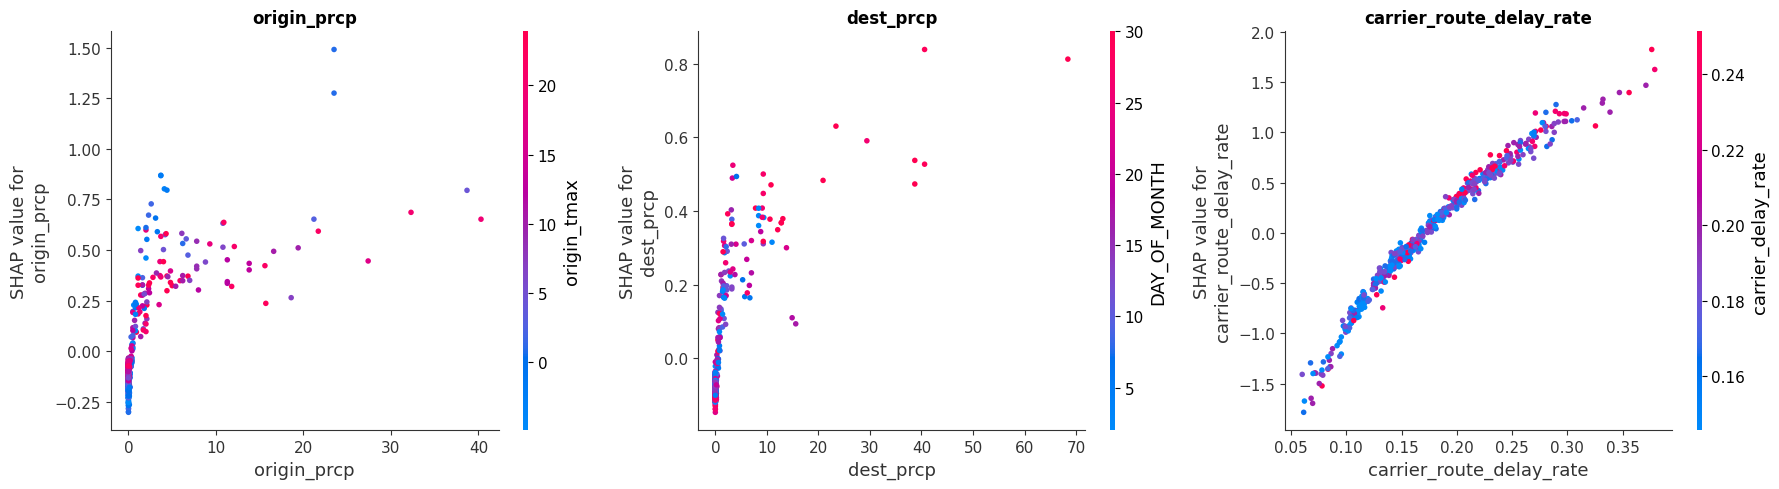

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, ["origin_prcp", "dest_prcp", "carrier_route_delay_rate"]):
    shap.dependence_plot(feat, sv, X_shap, feature_names=feature_names, ax=ax, show=False)
    ax.set_title(feat, fontweight="bold")

plt.tight_layout()
plt.savefig("models/dependence_plots.png", dpi=150, bbox_inches="tight")
plt.show()

### Top 20 Features by Mean |SHAP|

In [16]:
mean_abs_shap = np.abs(sv).mean(axis=0)
top20 = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False).head(20)

print("Top 20 features by mean |SHAP|:")
print(top20.to_string())

Top 20 features by mean |SHAP|:
carrier_route_delay_rate    0.516684
DAY_OF_MONTH                0.382032
origin_prcp                 0.187757
dest_prcp                   0.117526
CRS_DEP_HOUR                0.083066
DAY_OF_WEEK                 0.082249
lat_decimal                 0.072954
dep_hour_delay_rate         0.069404
origin_tmax                 0.065876
CRS_ARR_HOUR                0.064691
origin_tavg                 0.056753
carrier_delay_rate          0.050926
origin_tmin                 0.049413
lon_decimal                 0.042423
dest_tmax                   0.040046
origin_delay_rate           0.039169
origin_pres                 0.035799
dest_tmin                   0.034296
OP_UNIQUE_CARRIER           0.031131
origin_wspd                 0.031016


### Waterfall Plot – Single Prediction Breakdown

A cleaner alternative to the force plot. Shows how each feature pushes the prediction from the base value to the final output for one flight.

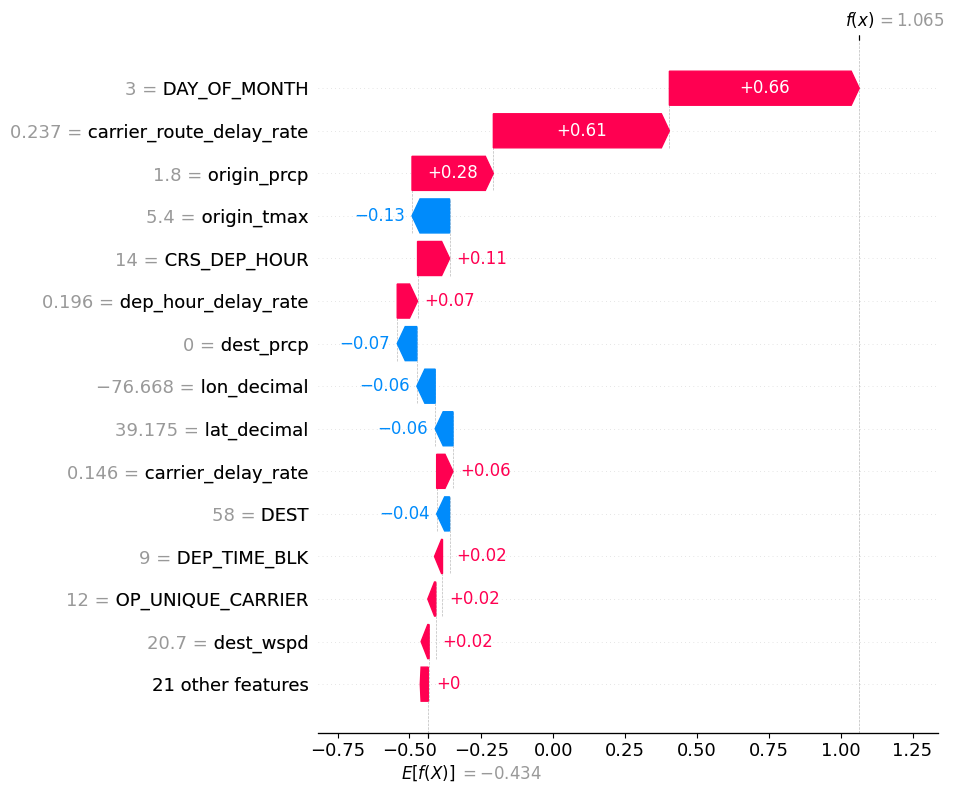

In [18]:
# Pick a delayed flight for a more interesting explanation
delayed_mask = y_test[sample_idx] == 1
delayed_idx  = np.where(delayed_mask)[0][0]  # first delayed flight in sample

explanation = shap.Explanation(
    values=sv[delayed_idx],
    base_values=base_val,
    data=X_shap.iloc[delayed_idx].values,
    feature_names=feature_names,
)

plt.figure(figsize=(10, 8))
shap.waterfall_plot(explanation, max_display=15, show=True)

### Feature Category Contribution

Groups features into categories and shows the total SHAP contribution of each category. This answers: *"How much does weather matter vs. historical patterns vs. temporal features?"*

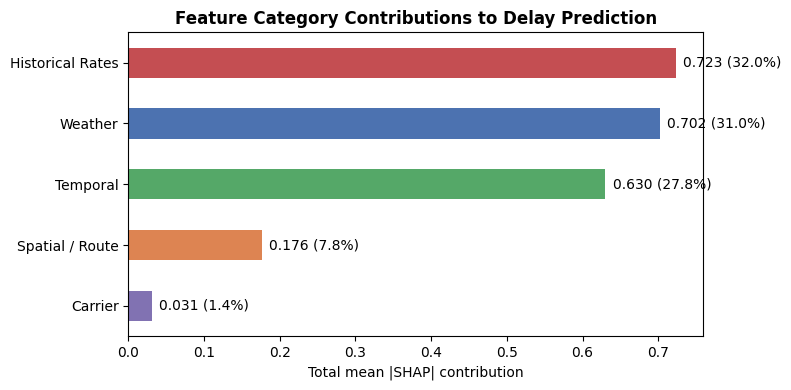


Category breakdown:
  Historical Rates    : 0.723 (32.0%)
    carrier_route_delay_rate      : 0.5167
    dep_hour_delay_rate           : 0.0694
    carrier_delay_rate            : 0.0509
    origin_delay_rate             : 0.0392
    dest_delay_rate               : 0.0209
    route_delay_rate              : 0.0131
    dep_block_delay_rate          : 0.0128
    month_delay_rate              : 0.0000
  Weather             : 0.702 (31.0%)
    origin_prcp                   : 0.1878
    dest_prcp                     : 0.1175
    origin_tmax                   : 0.0659
    origin_tavg                   : 0.0568
    origin_tmin                   : 0.0494
    dest_tmax                     : 0.0400
    origin_pres                   : 0.0358
    dest_tmin                     : 0.0343
    origin_wspd                   : 0.0310
    dest_wspd                     : 0.0305
    dest_tavg                     : 0.0279
    dest_pres                     : 0.0251
  Temporal            : 0.630 (27.8%)
    D

In [19]:
# Categorize features
weather_feats    = [f for f in feature_names if f.startswith(("origin_", "dest_")) and "rate" not in f]
historical_feats = [f for f in feature_names if f.endswith("_rate")]
temporal_feats   = ["YEAR", "MONTH", "DAY_OF_MONTH", "DAY_OF_WEEK", "CRS_DEP_HOUR",
                    "CRS_ARR_HOUR", "IS_WEEKEND", "DEP_TIME_BLK"]
spatial_feats    = ["lat_decimal", "lon_decimal", "altitude", "ORIGIN", "DEST", "DISTANCE"]
other_feats      = ["OP_UNIQUE_CARRIER"]

categories = {
    "Weather":           weather_feats,
    "Historical Rates":  historical_feats,
    "Temporal":          [f for f in temporal_feats if f in feature_names],
    "Spatial / Route":   [f for f in spatial_feats if f in feature_names],
    "Carrier":           [f for f in other_feats if f in feature_names],
}

# Sum mean |SHAP| per category
shap_series = pd.Series(mean_abs_shap, index=feature_names)
cat_importance = {}
for cat, feats in categories.items():
    cat_importance[cat] = shap_series[feats].sum()

cat_df = pd.Series(cat_importance).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = {"Weather": "#4C72B0", "Historical Rates": "#C44E52",
          "Temporal": "#55A868", "Spatial / Route": "#DD8452", "Carrier": "#8172B2"}
bar_colors = [colors.get(c, "#999999") for c in cat_df.index]
cat_df.plot.barh(ax=ax, color=bar_colors)
ax.set_xlabel("Total mean |SHAP| contribution")
ax.set_title("Feature Category Contributions to Delay Prediction", fontweight="bold")

# Add percentage labels
total = cat_df.sum()
for i, (val, name) in enumerate(zip(cat_df.values, cat_df.index)):
    ax.text(val + 0.01, i, f"{val:.3f} ({val/total*100:.1f}%)", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("models/category_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCategory breakdown:")
for cat in cat_df.sort_values(ascending=False).index:
    pct = cat_df[cat] / total * 100
    print(f"  {cat:20s}: {cat_df[cat]:.3f} ({pct:.1f}%)")
    for f in sorted(categories[cat], key=lambda x: shap_series.get(x, 0), reverse=True):
        if f in feature_names:
            print(f"    {f:30s}: {shap_series[f]:.4f}")